In [6]:
!git checkout -b phase2/feature/digit-recognition

Switched to a new branch 'phase2/feature/digit-recognition'


In [57]:
!git config user.email "yekta1382.sharifpour@gmail.com"
!git config user.name "yektasharifpour"

## Block 2.1 — Load Digit Datasets (MNIST + Hoda)
Purpose: load English (MNIST) and Persian (Hoda) digit datasets as the foundation for a combined 10-class digit classifier (1-9 + empty).
Roadmap phase: Phase 2
Files: digit_recognition/
Expected output: sample digit images from both datasets displayed, with shapes confirmed

In [20]:
!git clone https://github.com/amir-saniyan/HodaDatasetReader.git
!ls HodaDatasetReader

Cloning into 'HodaDatasetReader'...
remote: Enumerating objects: 24, done.
remote: Total 24 (delta 0), reused 0 (delta 0), pack-reused 24 (from 1)
Receiving objects: 100% (24/24), 6.34 MiB | 14.43 MiB/s, done.
Resolving deltas: 100% (6/6), done.
dataset_PRL.pdf		   Figure_1.png		 main.py
DigitDB			   Figure_2.png		 README.md
Farsi_Digits_Sample_1.gif  HodaDatasetReader.py
Farsi_Digits_Sample_2.gif  LICENSE


MNIST train size: 60000
MNIST test size: 10000


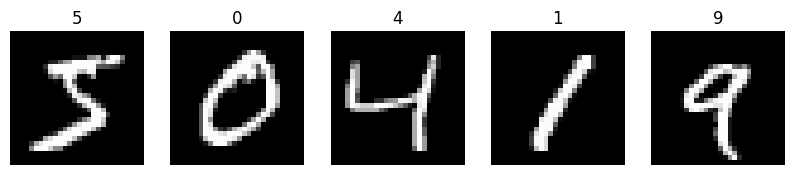

In [21]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([transforms.ToTensor()])

mnist_train = torchvision.datasets.MNIST(root="./datasets", train=True, download=True, transform=transform)
mnist_test = torchvision.datasets.MNIST(root="./datasets", train=False, download=True, transform=transform)

print("MNIST train size:", len(mnist_train))
print("MNIST test size:", len(mnist_test))

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    img, label = mnist_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.show()

In [22]:
!ls HodaDatasetReader

dataset_PRL.pdf		   Figure_1.png		 main.py
DigitDB			   Figure_2.png		 README.md
Farsi_Digits_Sample_1.gif  HodaDatasetReader.py
Farsi_Digits_Sample_2.gif  LICENSE


In [23]:
!ls HodaDatasetReader/DigitDB

 RemainingSamples.cdb  'Test 20000.cdb'  'Train 60000.cdb'


In [24]:
!cat HodaDatasetReader/main.py

# *-* coding: utf-8 *-*

from matplotlib import pyplot as plt
from HodaDatasetReader import read_hoda_cdb, read_hoda_dataset

print('################################################################################')
print()

# type(train_images):  <class 'list'>
# len(train_images):  60000
#
# type(train_images[ i ]): <class 'numpy.ndarray'>
# train_images[ i ].dtype: uint8
# train_images[ i ].min(): 0
# train_images[ i ].max(): 255
# train_images[ i ].shape: (HEIGHT, WIDTH)
#
# type(train_labels):  <class 'list'>
# len(train_labels):  60000
#
# type(train_labels[ i ]): <class 'int'>
# train_labels[ i ]: 0...9
print('Reading Train 60000.cdb ...')
train_images, train_labels = read_hoda_cdb('./DigitDB/Train 60000.cdb')


# type(test_images):  <class 'list'>
# len(test_images):  20000
#
# type(test_images[ i ]): <class 'numpy.ndarray'>
# test_images[ i ].dtype: uint8
# test_images[ i ].min(): 0
# test_images[ i ].max(): 255
# test_images[ i ].shape: (HEIGHT, WIDTH)
#
# type(test_labels): 

Hoda train shape: (60000, 28, 28, 1) (60000,)
Hoda test shape: (20000, 28, 28, 1) (20000,)


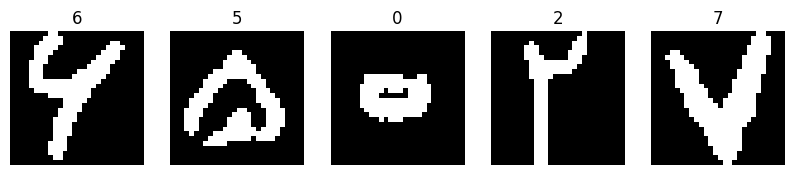

In [30]:
import sys
sys.path.append("HodaDatasetReader")
from HodaDatasetReader import read_hoda_dataset

X_hoda_train, Y_hoda_train = read_hoda_dataset(
    dataset_path="HodaDatasetReader/DigitDB/Train 60000.cdb",
    images_height=28,
    images_width=28,
    one_hot=False,
    reshape=False
)

X_hoda_test, Y_hoda_test = read_hoda_dataset(
    dataset_path="HodaDatasetReader/DigitDB/Test 20000.cdb",
    images_height=28,
    images_width=28,
    one_hot=False,
    reshape=False
)

print("Hoda train shape:", X_hoda_train.shape, Y_hoda_train.shape)
print("Hoda test shape:", X_hoda_test.shape, Y_hoda_test.shape)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_hoda_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(str(int(Y_hoda_train[i])))
    ax.axis("off")
plt.show()

## Block 2.2 — Merge Datasets
Purpose: combine MNIST (English) and Hoda (Persian) digit images into a single unified dataset for training one 10-class classifier that recognizes both scripts.
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: uses output of Block 2.1 and 2.1b
Expected output: combined dataset size printed, sample images from both scripts shown together

Combined train: (120000, 28, 28) (120000,)
Combined test: (30000, 28, 28) (30000,)


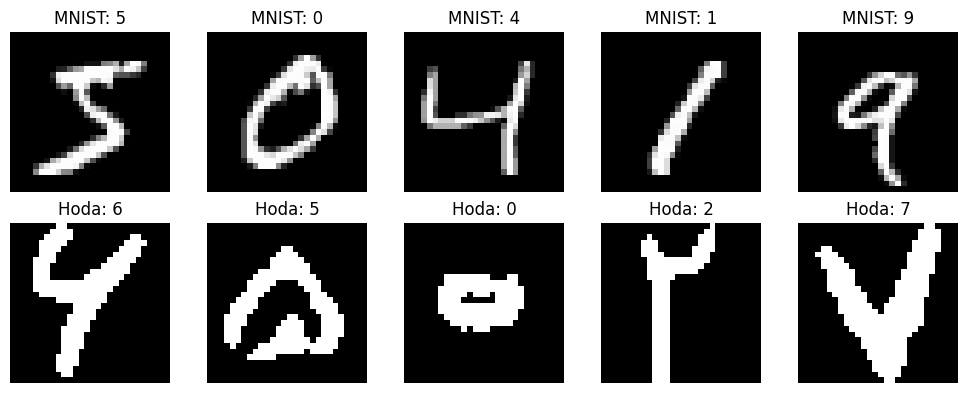

In [31]:
import numpy as np

# Convert MNIST (torch tensors) to numpy arrays matching Hoda's format
mnist_train_images = np.stack([np.array(img.squeeze()) for img, _ in mnist_train])
mnist_train_labels = np.array([label for _, label in mnist_train])

mnist_test_images = np.stack([np.array(img.squeeze()) for img, _ in mnist_test])
mnist_test_labels = np.array([label for _, label in mnist_test])

# MNIST pixel values are 0.0-1.0 floats (from ToTensor); Hoda's are already 0.0-1.0 floats too
hoda_train_images = X_hoda_train.reshape(-1, 28, 28)
hoda_train_labels = Y_hoda_train.astype(int)

hoda_test_images = X_hoda_test.reshape(-1, 28, 28)
hoda_test_labels = Y_hoda_test.astype(int)

# Combine
combined_train_images = np.concatenate([mnist_train_images, hoda_train_images], axis=0)
combined_train_labels = np.concatenate([mnist_train_labels, hoda_train_labels], axis=0)

combined_test_images = np.concatenate([mnist_test_images, hoda_test_images], axis=0)
combined_test_labels = np.concatenate([mnist_test_labels, hoda_test_labels], axis=0)

print("Combined train:", combined_train_images.shape, combined_train_labels.shape)
print("Combined test:", combined_test_images.shape, combined_test_labels.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(mnist_train_images[i], cmap="gray")
    axes[0, i].set_title(f"MNIST: {mnist_train_labels[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(hoda_train_images[i], cmap="gray")
    axes[1, i].set_title(f"Hoda: {hoda_train_labels[i]}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## Block 2.3 — Empty Cell Class (Real + Synthetic)
Purpose: build the 10th class (label 9... or 10, see note) representing empty cells, combining real examples from Phase 1 checkpoints with synthetic generated blanks.
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: uses Phase 1 checkpoints (checkpoints/phase1/*.npz), combines with Block 2.2 output
Expected output: empty-cell samples displayed (real and synthetic), final full 10-class dataset shapes printed

In [39]:
import glob
import cv2

checkpoint_files = glob.glob("checkpoints/phase1/*.npz")
print(f"Found {len(checkpoint_files)} Phase 1 checkpoints")

real_empty_cells = []
for cp_path in checkpoint_files:
    data = np.load(cp_path, allow_pickle=True)
    cells = data["cells"]
    empty_flags = data["empty_flags"]
    for cell, is_empty in zip(cells, empty_flags):
        if is_empty:
            resized = cv2.resize(cell.astype(np.uint8), (28, 28))
            real_empty_cells.append(resized.astype("float32") / 255.0)

real_empty_cells = np.array(real_empty_cells)
print("Real empty cells collected:", real_empty_cells.shape)

Found 17 Phase 1 checkpoints
Real empty cells collected: (833, 28, 28)


Synthetic empty cells generated: (11000, 28, 28)


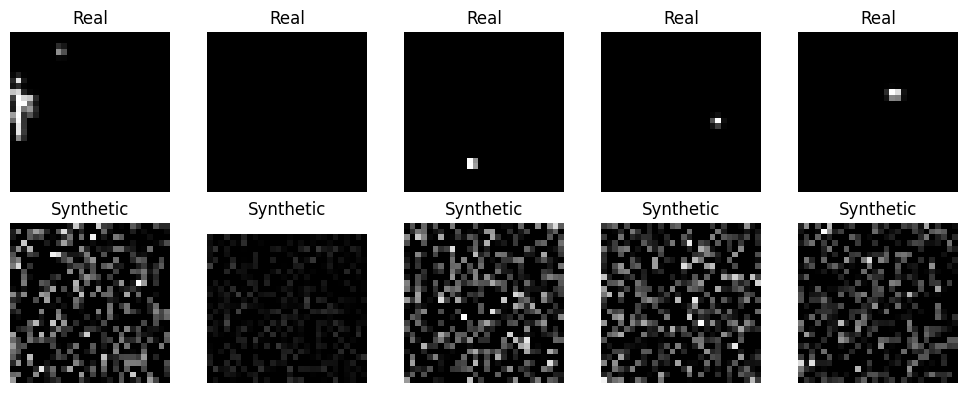

In [41]:
def generate_synthetic_empty(n_samples=1000, size=28):
    samples = []
    for _ in range(n_samples):
        img = np.zeros((size, size), dtype="float32")

        # Simulate faint background noise/texture
        noise = np.random.normal(0, 0.03, (size, size))
        img = np.clip(img + noise, 0, 1)

        # Occasionally add a faint grid-line remnant fragment, like real leftover borders
        if np.random.rand() < 0.3:
            edge = np.random.choice(["top", "bottom", "left", "right"])
            thickness = np.random.randint(1, 3)
            if edge == "top":
                img[:thickness, :] = np.random.uniform(0.3, 0.6)
            elif edge == "bottom":
                img[-thickness:, :] = np.random.uniform(0.3, 0.6)
            elif edge == "left":
                img[:, :thickness] = np.random.uniform(0.3, 0.6)
            else:
                img[:, -thickness:] = np.random.uniform(0.3, 0.6)

        samples.append(img)
    return np.array(samples)

synthetic_empty_cells = generate_synthetic_empty(n_samples=11000)
print("Synthetic empty cells generated:", synthetic_empty_cells.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(real_empty_cells[i], cmap="gray")
    axes[0, i].set_title("Real")
    axes[0, i].axis("off")

    axes[1, i].imshow(synthetic_empty_cells[i], cmap="gray")
    axes[1, i].set_title("Synthetic")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

#### reduce noise and fix the display scaling


Synthetic empty cells generated: (11000, 28, 28)


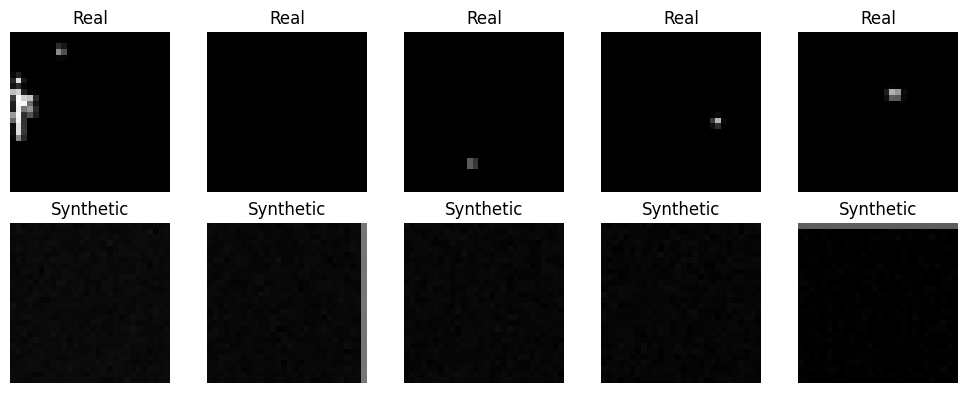

In [45]:
def generate_synthetic_empty(n_samples=1000, size=28):
    samples = []
    for _ in range(n_samples):
        base_level = np.random.uniform(0.0, 0.05)
        img = np.full((size, size), base_level, dtype="float32")

        noise = np.random.normal(0, 0.008, (size, size))
        img = np.clip(img + noise, 0, 1)

        if np.random.rand() < 0.3:
            edge = np.random.choice(["top", "bottom", "left", "right"])
            thickness = np.random.randint(1, 3)
            if edge == "top":
                img[:thickness, :] = np.random.uniform(0.3, 0.6)
            elif edge == "bottom":
                img[-thickness:, :] = np.random.uniform(0.3, 0.6)
            elif edge == "left":
                img[:, :thickness] = np.random.uniform(0.3, 0.6)
            else:
                img[:, -thickness:] = np.random.uniform(0.3, 0.6)

        samples.append(img)
    return np.array(samples)

synthetic_empty_cells = generate_synthetic_empty(n_samples=11000)
print("Synthetic empty cells generated:", synthetic_empty_cells.shape)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):
    axes[0, i].imshow(real_empty_cells[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("Real")
    axes[0, i].axis("off")

    axes[1, i].imshow(synthetic_empty_cells[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("Synthetic")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## Block 2.4 — Final Dataset Assembly
Purpose: combine MNIST digits 1-9, Hoda digits 1-9, real empty cells, and synthetic empty cells into one final labeled dataset (label 0 = empty, labels 1-9 = digits).
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: uses output of Block 2.2, 2.3, 2.3b
Expected output: final combined dataset shape and class distribution printed

In [46]:
# Filter out digit-0 samples from MNIST/Hoda (Sudoku digits are 1-9 only; 0 is reserved for "empty")
train_mask = combined_train_labels != 0
digits_train_images = combined_train_images[train_mask]
digits_train_labels = combined_train_labels[train_mask]

test_mask = combined_test_labels != 0
digits_test_images = combined_test_images[test_mask]
digits_test_labels = combined_test_labels[test_mask]

# Build empty-class labels (all zeros)
all_empty_images = np.concatenate([real_empty_cells, synthetic_empty_cells], axis=0)
all_empty_labels = np.zeros(len(all_empty_images), dtype=int)

# Split empty cells into train/test (80/20), matching the digit data's train/test separation
n_empty = len(all_empty_images)
shuffle_idx = np.random.permutation(n_empty)
split_point = int(n_empty * 0.8)

empty_train_images = all_empty_images[shuffle_idx[:split_point]]
empty_train_labels = all_empty_labels[shuffle_idx[:split_point]]
empty_test_images = all_empty_images[shuffle_idx[split_point:]]
empty_test_labels = all_empty_labels[shuffle_idx[split_point:]]

# Final merge
final_train_images = np.concatenate([digits_train_images, empty_train_images], axis=0)
final_train_labels = np.concatenate([digits_train_labels, empty_train_labels], axis=0)

final_test_images = np.concatenate([digits_test_images, empty_test_images], axis=0)
final_test_labels = np.concatenate([digits_test_labels, empty_test_labels], axis=0)

print("Final train:", final_train_images.shape, final_train_labels.shape)
print("Final test:", final_test_images.shape, final_test_labels.shape)

print("\nClass distribution (train):")
for c in range(10):
    count = np.sum(final_train_labels == c)
    print(f"  Class {c}: {count}")

Final train: (117543, 28, 28) (117543,)
Final test: (29387, 28, 28) (29387,)

Class distribution (train):
  Class 0: 9466
  Class 1: 12742
  Class 2: 11958
  Class 3: 12131
  Class 4: 11842
  Class 5: 11421
  Class 6: 11918
  Class 7: 12265
  Class 8: 11851
  Class 9: 11949


## Block 2.5 — Model Architecture
Purpose: define a CNN for 10-class digit classification (0=empty, 1-9=digits).
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: consumes final_train_images/labels from Block 2.4
Expected output: model summary printed

In [47]:
import torch.nn as nn
import torch.nn.functional as F

class DigitClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 28x28 -> 14x14
        x = self.pool(F.relu(self.conv2(x)))   # 14x14 -> 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DigitClassifier(num_classes=10).to(device)
print(model)
print("\nUsing device:", device)

DigitClassifier(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Using device: cpu


## Block 2.6 — Data Loaders and Augmentation
Purpose: wrap the final dataset into PyTorch DataLoaders with augmentation (rotation, shift) for more robust training, per spec requirement.
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: consumes final_train_images/labels, final_test_images/labels from Block 2.4
Expected output: confirmed batch shapes from the loader

In [48]:
from torch.utils.data import Dataset, DataLoader

class DigitDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].astype("float32")
        label = int(self.labels[idx])

        if self.augment:
            # Random small rotation
            angle = np.random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((14, 14), angle, 1.0)
            img = cv2.warpAffine(img, M, (28, 28))

            # Random small shift
            tx, ty = np.random.uniform(-2, 2, size=2)
            M_shift = np.float32([[1, 0, tx], [0, 1, ty]])
            img = cv2.warpAffine(img, M_shift, (28, 28))

        img = np.clip(img, 0, 1)
        img_tensor = torch.tensor(img).unsqueeze(0)  # add channel dim: (1, 28, 28)
        return img_tensor, label

train_dataset = DigitDataset(final_train_images, final_train_labels, augment=True)
test_dataset = DigitDataset(final_test_images, final_test_labels, augment=False)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Sanity check
sample_batch_images, sample_batch_labels = next(iter(train_loader))
print("Batch images shape:", sample_batch_images.shape)
print("Batch labels shape:", sample_batch_labels.shape)

Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])


## Block 2.7 — Training Loop
Purpose: train the CNN on the combined dataset using CrossEntropy Loss, tracking accuracy per epoch (per spec requirement).
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: uses model from Block 2.5, loaders from Block 2.6
Expected output: training/validation loss and accuracy curves per epoch

In [50]:
import torch.optim as optim
import os
from tqdm.notebook import tqdm
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 12
checkpoint_dir = "checkpoints/phase2"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = f"{checkpoint_dir}/digit_classifier_latest.pt"

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
start_epoch = 0

# Resume if a checkpoint already exists (per Checkpoint Policy)
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    history = checkpoint["history"]
    start_epoch = checkpoint["epoch"] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        progress_bar.set_postfix(loss=running_loss/total, acc=correct/total)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    test_loss = val_loss / val_total
    test_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

    # Save checkpoint after every epoch
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "history": history
    }, checkpoint_path)

Epoch 1/12:   0%|          | 0/1837 [00:00<?, ?it/s]

Epoch 1/12 | Train Loss: 0.1589, Train Acc: 0.9505 | Test Loss: 0.0667, Test Acc: 0.9787


Epoch 2/12:   0%|          | 0/1837 [00:00<?, ?it/s]

Epoch 2/12 | Train Loss: 0.1154, Train Acc: 0.9648 | Test Loss: 0.0533, Test Acc: 0.9833


Epoch 3/12:   0%|          | 0/1837 [00:00<?, ?it/s]

...

Epoch 10/12 | Train Loss: 0.0506, Train Acc: 0.9847 | Test Loss: 0.0298, Test Acc: 0.9900


Epoch 11/12:   0%|          | 0/1837 [00:00<?, ?it/s]

Epoch 11/12 | Train Loss: 0.0509, Train Acc: 0.9841 | Test Loss: 0.0298, Test Acc: 0.9899


Epoch 12/12:   0%|          | 0/1837 [00:00<?, ?it/s]

Epoch 12/12 | Train Loss: 0.0477, Train Acc: 0.9853 | Test Loss: 0.0259, Test Acc: 0.9918


## Block 2.8 — Training Curves
Purpose: visualize loss and accuracy over epochs, per spec deliverable requirement.
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: uses history from Block 2.7
Expected output: loss and accuracy curve plots

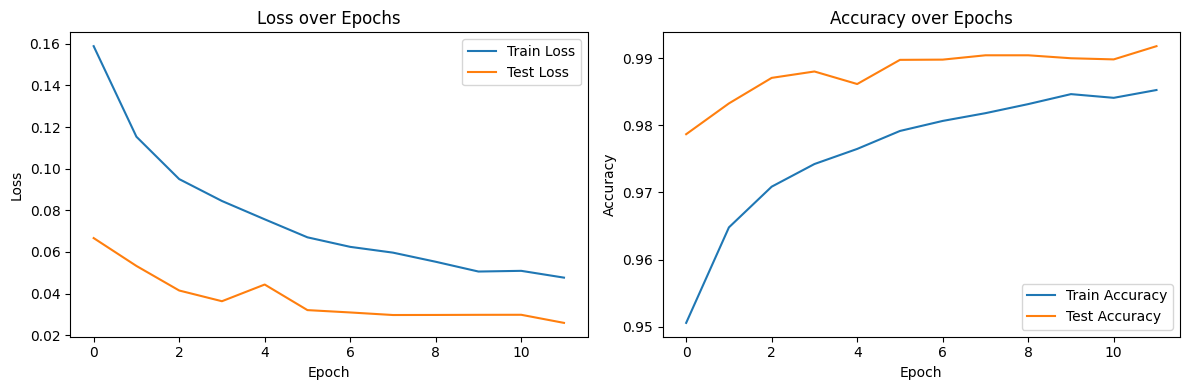

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["test_loss"], label="Test Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over Epochs")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Accuracy")
axes[1].plot(history["test_acc"], label="Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].legend()

plt.tight_layout()
plt.savefig("checkpoints/phase2/training_curves.png")
plt.show()

## Block 2.9 — Confusion Matrix & Error Analysis
Purpose: evaluate per-class performance, especially checking if the "empty" class (0) is confused with digits, per spec deliverable requirement.
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: uses trained model from Block 2.7, test_loader from Block 2.6
Expected output: confusion matrix heatmap, misclassified sample images

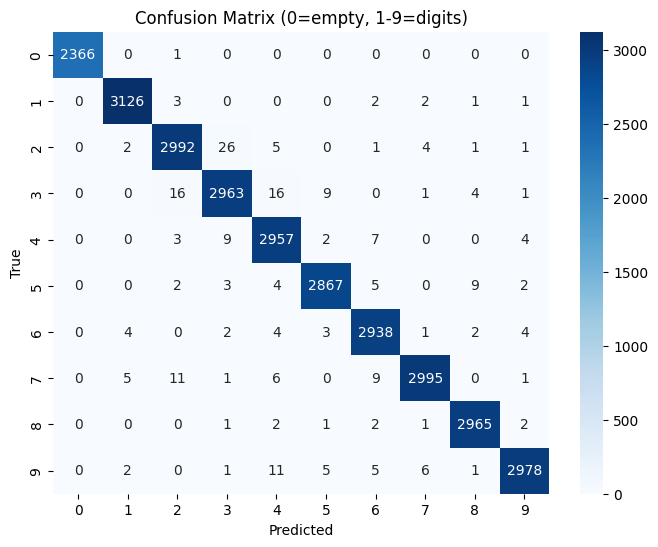

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2367
           1       1.00      1.00      1.00      3135
           2       0.99      0.99      0.99      3032
           3       0.99      0.98      0.99      3010
           4       0.98      0.99      0.99      2982
           5       0.99      0.99      0.99      2892
           6       0.99      0.99      0.99      2958
           7       1.00      0.99      0.99      3028
           8       0.99      1.00      1.00      2974
           9       0.99      0.99      0.99      3009

    accuracy                           0.99     29387
   macro avg       0.99      0.99      0.99     29387
weighted avg       0.99      0.99      0.99     29387



In [52]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_images.extend(images.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (0=empty, 1-9=digits)")
plt.savefig("checkpoints/phase2/confusion_matrix.png")
plt.show()

print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

## Block 2.10 — Misclassification Examples
Purpose: visually inspect actual misclassified samples for the error-analysis deliverable.
Roadmap phase: Phase 2
Files: digit_recognition/
Related blocks: uses predictions from Block 2.9
Expected output: grid of misclassified images with true/predicted labels

Total misclassified: 240 out of 29387


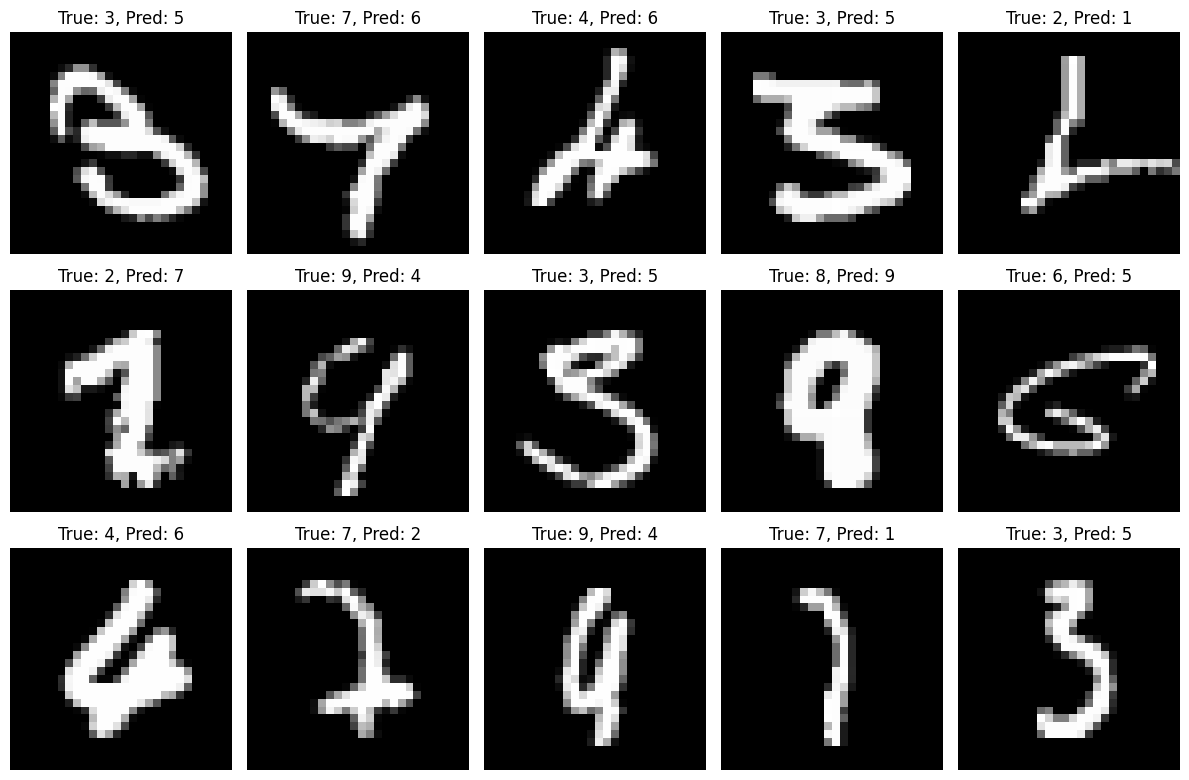

In [53]:
misclassified_idx = np.where(all_preds != all_labels)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(all_labels)}")

n_show = min(15, len(misclassified_idx))
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for i, idx in enumerate(misclassified_idx[:n_show]):
    ax = axes[i // 5, i % 5]
    ax.imshow(all_images[idx].squeeze(), cmap="gray")
    ax.set_title(f"True: {all_labels[idx]}, Pred: {all_preds[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("checkpoints/phase2/misclassified_examples.png")
plt.show()

## Block 2.11 — Final model checkpoint

In [56]:
import os
os.makedirs("models", exist_ok=True)
torch.save({
    "model_state": model.state_dict(),
    "num_classes": 10,
    "class_mapping": "0=empty, 1-9=digits",
    "test_accuracy": history["test_acc"][-1],
    "architecture": "DigitClassifier (2 conv layers + 2 fc layers)"
}, "models/digit_classifier_final.pt")

print("Final model saved to models/digit_classifier_final.pt")

Final model saved to models/digit_classifier_final.pt


In [55]:
print(history["test_acc"][-1])

0.9918331234899785


In [59]:
!git status

On branch phase2/feature/digit-recognition
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	HodaDatasetReader/
	checkpoints/phase2/
	datasets/MNIST/
	models/

nothing added to commit but untracked files present (use "git add" to track)


In [60]:
!git add .
!git commit -m "feat: Phase 2 digit recognition complete - 99.18% test accuracy, combined MNIST+Hoda 10-class model"

hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> HodaDatasetReader
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached HodaDatasetReader
hint: 
hint: See "git help submodule" for more information.
[phase2/feature/digit-recognition 11129fc] feat: Phase 2 digit recognition complete - 99.18% test accuracy, combined MNIST+Hoda 10-class model
 14 files changed, 1 insertion(+)
 create mode 160000 HodaDatasetReader
 create mode 100644 checkpoints/phase2/confusion_matrix.png
 create mode 100644 checkpoints/phase2/digit_classifier_latest.pt
 create mode 100644 checkpoints/phase2/misclassified_examples.png
 create mode 100644 checkpoints/phase2/training_curves.png
 create mode 100644 dat

In [61]:
!git push

fatal: The current branch phase2/feature/digit-recognition has no upstream branch.
To push the current branch and set the remote as upstream, use

    git push --set-upstream origin phase2/feature/digit-recognition



In [62]:
!git rm --cached HodaDatasetReader

rm 'HodaDatasetReader'


In [63]:
!rm -rf HodaDatasetReader/.git

In [64]:
!git add HodaDatasetReader
!git status

On branch phase2/feature/digit-recognition
Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	deleted:    HodaDatasetReader
	new file:   HodaDatasetReader/.gitignore
	new file:   HodaDatasetReader/DigitDB/RemainingSamples.cdb
	new file:   HodaDatasetReader/DigitDB/Test 20000.cdb
	new file:   HodaDatasetReader/DigitDB/Train 60000.cdb
	new file:   HodaDatasetReader/Farsi_Digits_Sample_1.gif
	new file:   HodaDatasetReader/Farsi_Digits_Sample_2.gif
	new file:   HodaDatasetReader/Figure_1.png
	new file:   HodaDatasetReader/Figure_2.png
	new file:   HodaDatasetReader/HodaDatasetReader.py
	new file:   HodaDatasetReader/LICENSE
	new file:   HodaDatasetReader/README.md
	new file:   HodaDatasetReader/dataset_PRL.pdf
	new file:   HodaDatasetReader/main.py



In [65]:
!git commit -m "fix: properly track HodaDatasetReader files (remove nested git repo)"

[phase2/feature/digit-recognition 032cdee] fix: properly track HodaDatasetReader files (remove nested git repo)
 14 files changed, 694 insertions(+), 1 deletion(-)
 delete mode 160000 HodaDatasetReader
 create mode 100644 HodaDatasetReader/.gitignore
 create mode 100644 HodaDatasetReader/DigitDB/RemainingSamples.cdb
 create mode 100644 HodaDatasetReader/DigitDB/Test 20000.cdb
 create mode 100644 HodaDatasetReader/DigitDB/Train 60000.cdb
 create mode 100644 HodaDatasetReader/Farsi_Digits_Sample_1.gif
 create mode 100644 HodaDatasetReader/Farsi_Digits_Sample_2.gif
 create mode 100644 HodaDatasetReader/Figure_1.png
 create mode 100644 HodaDatasetReader/Figure_2.png
 create mode 100644 HodaDatasetReader/HodaDatasetReader.py
 create mode 100644 HodaDatasetReader/LICENSE
 create mode 100644 HodaDatasetReader/README.md
 create mode 100644 HodaDatasetReader/dataset_PRL.pdf
 create mode 100644 HodaDatasetReader/main.py
